# Analyse cocktail entropy and enthalpy

In [1]:
import os
import sys
import torch
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils_mean_field import *
from script_mean_field_covid import *

main_path = "../"

sys.path.append(main_path + "PGM/source/")
sys.path.append(main_path + "PGM/utilities/")
import utilities, Proteins_utils, sequence_logo, plots_utils
sys.path.append(main_path + "covid/")
os.chdir(main_path + "covid/")

from global_variables import *
# from AB_RBM_EnergyModel import *
# from utils_evaluate_seq import *
os.chdir('../mean_field_theory')
os.listdir()

e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights


Loaded 29 KD vectors


C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


['beta_ab influence.ipynb',
 'D_10_cocktail_beta_summary.csv',
 'Figure 4ab.ipynb',
 'Figure 4d.ipynb',
 'Figure 5.ipynb',
 'Figure 5f.ipynb',
 'Figure S.ipynb',
 'nexstrain comparison.ipynb',
 'obsolete',
 'results_scripts',
 'results_scripts old',
 'script_cocktail_analysis.py',
 'script_get_proba.py',
 'script_get_proba_lattice.py',
 'script_mean_field_all_cocktails_covid.py',
 'script_mean_field_cocktail_covid.py',
 'script_mean_field_covid copy 2.py',
 'script_mean_field_covid copy.py',
 'script_mean_field_covid.py',
 'script_mean_field_lattice copy.py',
 'script_mean_field_lattice.py',
 'Table 1.ipynb',
 'utils_mean_field copy.py',
 'utils_mean_field.py',
 'utils_rbm_mean_field copy 2.py',
 'utils_rbm_mean_field copy.py',
 'utils_rbm_mean_field.py',
 '__pycache__']

# Read results

In [2]:
PROT_INIT = Proteins_utils.load_FASTA("../covid/exp_data/wt_omicron.fasta")[0]
PROT_INIT = PROT_INIT[BEGIN:-END]


In [3]:
L=PROT_INIT.shape[0]
Q = 20






# Escape

In [4]:
ab_names= list(ESCAPE_VECTORS.keys())
ab_focused = ["REGN10933", "REGN10987",'LY-CoV555','LY-CoV016']
# ab_focused = ['LY-CoV555','LY-CoV016']
indexes_abs = [ab_names.index(ab) for ab in ab_focused]
ab_names

['COV2-2050',
 'COV2-2082',
 'COV2-2094',
 'COV2-2096',
 'COV2-2130',
 'COV2-2165',
 'COV2-2196',
 'COV2-2479',
 'COV2-2499',
 'COV2-2677',
 'COV2-2832',
 'CR3022',
 'LY-CoV016',
 'LY-CoV555',
 'REGN10933',
 'REGN10987',
 'S2D106',
 'S2E12',
 'S2H13',
 'S2H14',
 'S2H58',
 'S2H97',
 'S2X16',
 'S2X227',
 'S2X259',
 'S2X35',
 'S2X58',
 'S304',
 'S309']


## Get values

In [5]:
ab_function_list = create_ab_functions(n_ab=29, beta_ab=1,L=L)
gamma_f_list = create_gamma_functions(
    torch.tensor(RBM.hlayer.gamma_plus),
    torch.tensor(RBM.hlayer.gamma_minus),
    torch.tensor(RBM.hlayer.theta_plus),
    torch.tensor(RBM.hlayer.theta_minus),
    L
)


# Combine weights and functions
selection_coeff_list = []
selection_coeff_list_gamma_only = []
selection_coeff_list_gamma_only.extend(create_ab_functions(n_ab=29, beta_ab=0,L=L))
selection_coeff_list_gamma_only.extend(gamma_f_list)

selection_coeff_list.extend(create_ab_functions(n_ab=29, beta_ab=1,L=L))
selection_coeff_list.extend(gamma_f_list)



# Antibody weights
ab_names = list(ESCAPE_VECTORS.keys())
wab = np.zeros((L, Q, len(ab_names)))
for idx, ab in enumerate(ab_names):
    w_ab = ESCAPE_VECTORS[ab].reshape(L, Q)  # "no bias"
    wab[:, :, idx] = w_ab

# make sure only<=0 coeffs
for i in range(len(ab_names)):
    if np.any(wab[:, :, i] > 0):
        raise ValueError(f"Escape vector {ab_names[i]} has positive coeffs")

# RBM weights
wgamma = np.transpose(RBM.weights[:, :, :], (1, 2, 0))
g = RBM.vlayer.fields
gamma_f_list = create_gamma_functions(
    torch.tensor(RBM.hlayer.gamma_plus),
    torch.tensor(RBM.hlayer.gamma_minus),
    torch.tensor(RBM.hlayer.theta_plus),
    torch.tensor(RBM.hlayer.theta_minus),
    L,
    beta_rbm=1,
)

w_components = []
name_array = []
w_components.append(wab)
name_array.extend(ab_names)
w_components.append(wgamma)
name_array.extend(["gamma " + str(i) for i in range(len(gamma_f_list))])
w = np.concatenate(w_components, axis=-1)


In [8]:



def get_zeta(mopt, selection_coeff_list):
    """
    returns potential of gamma and ab"""
    zeta_values = []
    zeta_values_gamma_only = []

    for j in range (mopt.shape[0]):
        zeta_values.append( Zeta(torch.tensor(mopt[j]), selection_coeff_list, L).detach().numpy())
        zeta_values_gamma_only.append( Zeta(torch.tensor(mopt[j]), selection_coeff_list_gamma_only, L).detach().numpy())
    zeta_values = np.array(zeta_values)
    zeta_values_gamma_only = np.array(zeta_values_gamma_only)
    return zeta_values_gamma_only, zeta_values-zeta_values_gamma_only # gamma potential, Ab potential
    

def get_phi(qopt,q_c):
    phi_values = Phi_cont(torch.tensor(qopt), q_c, L).detach().numpy()
    return phi_values


def get_field(path_proba):
    # bring the time axis to the front: (T, L, Q)
    path_proba = np.moveaxis(path_proba, 0, -1)   # if you really need this
    field      = np.empty(path_proba.shape[0])    # one value per time-step

    for t in range(path_proba.shape[0]):          # loop over timesteps
        field[t] = np.sum(path_proba[t] * g.T)    # element-wise product

    return -field 

def path_entropy_mean_field(mhat, qhat, mopt, qopt, w=w, g=g, PROT_INIT=PROT_INIT):
    #make sur eno inf
    if np.any(np.isinf(mhat)) or np.any(np.isinf(qhat)):
        print('mhat or qhat has inf values, returning NaN')
        return np.nan, None
    if np.any(np.isinf(mopt)) or np.any(np.isinf(qopt)):
        print('mopt or qopt has inf values, returning NaN')
        return np.nan, None
    sum_m_mhat=np.sum(np.sum(mhat*mopt, axis=0))
    sum_q_qhat=np.sum(np.sum(qhat*qopt, axis=0))
    grad_g_list = []
    sum_logZ=0
    for i in tqdm(range(PROT_INIT.shape[0])):

        Zi, grad_q, grad_m, grad_g=compute_transfer_matrix_Z_free_with_epsilon(Q, qhat, mhat, w[i], g[i],v1_fixed=PROT_INIT[i], 
                            beta_rbm=1)
        #make all tensors numpy arrays
        grad_q = grad_q.detach().numpy()
        grad_m = grad_m.detach().numpy()
        grad_g = grad_g.detach().numpy()#grad_g.shape == (T, Q)
        grad_g_list.append(grad_g)

        sum_logZ+=Zi
    

    sum_logZ=np.array(sum_logZ)
    print('sum logZ', sum_logZ)
    s=sum_logZ-sum_m_mhat-sum_q_qhat

    #shape of grad_g: L, T, Q
    grad_g_list = np.array(grad_g_list)
    print('grad_g_list',grad_g_list.shape)
    print('g',g.shape)

    sum_field_neg_energy = np.sum(grad_g_list * g[:, None, :]) 

    print('s=',s)
    print('sum_field_energy', sum_field_neg_energy)
    s = s - sum_field_neg_energy
    return s, grad_g_list
    



In [ ]:
path='mean_f_free_ab_beta_ab_1_D_1'
dir = 'results_scripts/covid_D_20'

import numpy as np
import os
import pandas as pd

# Replace these with your actual definitions
# selection_coeff_list, w, g, PROT_INIT
# get_zeta, get_phi, get_field, path_entropy_mean_field must be defined
ab_combos = ['REGN10933','COV2-2196', 'REGN10987', 'REGN10933_REGN10987','REGN10933_COV2-2196']

results=[]
beta_ab=0
# Load data
# mopt = np.load(os.path.join(dir, path, "mopt.npy"))
# qopt = np.load(os.path.join(dir, path, "qopt.npy"))
mopt = np.load(os.path.join(dir, path, "dm_array.npy"))[-1]
qopt = np.load(os.path.join(dir, path, "dq_array.npy"))[-1]
print(qopt)
mhat = np.load(os.path.join(dir, path, "mhat_array.npy"))[-1]
qhat = np.load(os.path.join(dir, path, "qhat_array.npy"))[-1]

print("mopt shape:", mopt.shape)
print("qopt shape:", qopt.shape)
print("mhat shape:", mhat.shape)
print("qhat shape:", qhat.shape)
path_entropy, field_proba = path_entropy_mean_field(
    mhat, qhat, mopt, qopt, w=w, g=g, PROT_INIT=PROT_INIT
)
print("Path entropy =", path_entropy)

path_entropy_np_c, field_proba = path_entropy_mean_field(
    mhat*0, qhat*0, mopt, qopt, w=w, g=g*0, PROT_INIT=PROT_INIT
)
print("Path entropy no constraint =", path_entropy_np_c)

path_entropy_indep, field_proba = path_entropy_mean_field(
    mhat*0, qhat*0, mopt, qopt, w=w, g=g, PROT_INIT=PROT_INIT
)
print("Path entropy indep constraint=", path_entropy_indep)
L=178
Q=20
T=20
s=np.log(L*(Q-1))*(T)
print("Path entropy one mutation per step=", s)


[4.38962063e-10 8.22863054e-08 6.82068026e+00 8.51711378e-03
 4.05391288e-08 2.94615724e-01 8.91175578e-02 8.37905738e-02
 7.57347302e-01 7.15858144e-01 9.40285373e-01 7.91306089e-01
 7.20649441e-01 6.87931407e-01 6.83510425e-01 6.87189173e-01
 6.80866728e-01 6.57532307e-01 6.25961551e-01 6.08854055e-01]
mopt shape: (21, 79)
qopt shape: (20,)
mhat shape: (21, 79)
qhat shape: (20,)


  0%|          | 0/178 [00:00<?, ?it/s]

100%|██████████| 178/178 [04:46<00:00,  1.61s/it]


sum logZ 30289.68409804424
grad_g_list (178, 21, 20)
g (178, 20)
s= 28482.48345886699
sum_field_energy 28446.8529072586
Path entropy = 35.630551608392125


100%|██████████| 178/178 [04:14<00:00,  1.43s/it]


sum logZ 10664.806893852181
grad_g_list (178, 21, 20)
g (178, 20)
s= 10664.806893852181
sum_field_energy 0.0
Path entropy no constraint = 10664.806893852181


100%|██████████| 178/178 [04:08<00:00,  1.40s/it]

sum logZ 32572.470604860926
grad_g_list (178, 21, 20)
g (178, 20)
s= 32572.470604860926
sum_field_energy 28001.758846392844
Path entropy indep constraint= 4570.711758468082
Path entropy one mutation per step= 0.9130587111751152


No constraint: 10664.81 (824436.69)
Independent field: 4570.71 (353336.21)
1 mutation/step: 162.52 (12563.86)
Model: 35.63 (2754.40)


C:\Users\maria\AppData\Local\Temp\ipykernel_25488\3138886146.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=entropy_data, x='Model', y='Entropy', palette='deep')


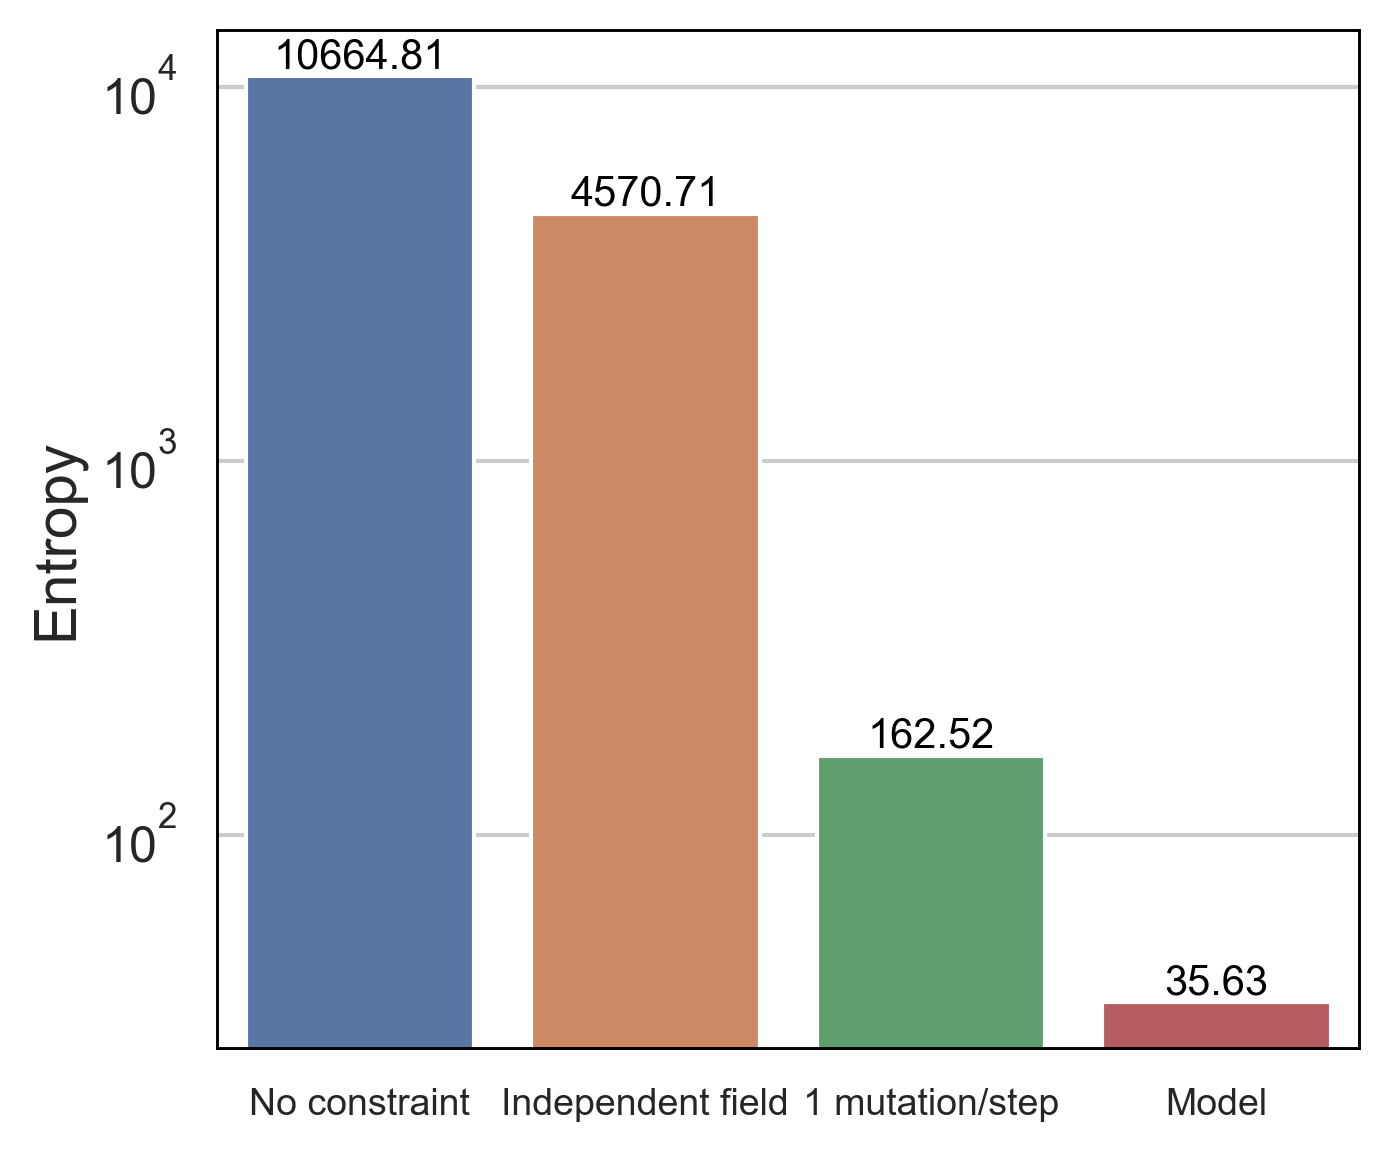

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Values from your script (replace these if dynamic)
entropy_constrained = path_entropy
entropy_no_constraint = path_entropy_np_c
entropy_independent = path_entropy_indep
entropy_one_mut_per_step = s

# Prepare DataFrame for plotting
entropy_data = pd.DataFrame({
    'Model': [
        'No constraint', 
        'Independent field', 
        '1 mutation/step',
                'Model', 

    ],
    'Entropy': [
        entropy_no_constraint, 
        entropy_independent, 
        entropy_one_mut_per_step,        entropy_constrained, 

    ]
})
#print 178*entropy/np.log(10)
for i in range(len(entropy_data)):
    print(f"{entropy_data['Model'][i]}: {entropy_data['Entropy'][i]:.2f} ({178*entropy_data['Entropy'][i]/np.log(10):.2f})")

# Plot settings
sns.set(style="whitegrid")
plt.figure(figsize=(5, 4), dpi=300)
ax = sns.barplot(data=entropy_data, x='Model', y='Entropy', palette='deep')

# Style the plot
# ax.set_title("Path Entropy under Different Models", fontsize=16)
ax.set_ylabel("Entropy", fontsize=14)
ax.set_xlabel("")
plt.xticks(fontsize=9)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.yscale('log')
# Add black spines
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.7)
#add values on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black', rotation=0)

# Optional: save figure
# plt.savefig("entropy_comparison.pdf")

plt.show()


In [15]:
entropy_data = pd.DataFrame({
    'Model': [
        'No constraint', 
        'Independent field', 
        '1 mutation/step',
                'Model', 

    ],
    'Entropy': [
        entropy_no_constraint, 
        entropy_independent, 
        entropy_one_mut_per_step,        entropy_constrained, 

    ]
})

#multiply by 178 and divide by log(10)
for i in range(len(entropy_data)):
    print(f"{entropy_data['Model'][i]}: {entropy_data['Entropy'][i]:.2f} ({entropy_data['Entropy'][i]/np.log(10):.2f})")

No constraint: 10664.81 (4631.67)
Independent field: 4570.71 (1985.03)
1 mutation/step: 162.52 (70.58)
Model: 35.63 (15.47)


In [16]:
np.log10(20)*20*178

4631.666784563773